In [22]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [23]:
# ── 載入 RT 資料並從 SourceFile 提取真正的 SubjectID ──

CLASS_NAMES = ['amateur', 'master', 'prof']

def extract_real_subject(source):
    m = re.match(r'(sub-\w+?)_ses-', source)
    return m.group(1) if m else source

def extract_session(source):
    m = re.search(r'_ses-[Ss]?[Ee]?[Ss]?[Ss]?0*(\d+)', source)
    return int(m.group(1)) if m else None

all_dfs = []
for g in CLASS_NAMES:
    df = pd.read_csv(f'D:/Tseng/圍棋/Integrated_RT_Results_with_Order.{g}.csv')
    df['Group'] = g
    df['RT_diff_ms'] = df['RT2_ms'] - df['RT1_ms']
    df['RealSubject'] = df['SourceFile'].apply(extract_real_subject)
    df['Session'] = df['SourceFile'].apply(extract_session)
    all_dfs.append(df)

df_all = pd.concat(all_dfs, ignore_index=True)

# 每人每 session 的平均 RT
rt_mean = df_all.groupby(['Group', 'RealSubject', 'Session'])['RT_diff_ms'].mean().reset_index()
rt_pivot = rt_mean.pivot_table(index=['Group', 'RealSubject'], columns='Session', values='RT_diff_ms')
rt_pivot.columns = ['ss01', 'ss02', 'ss03']
rt_pivot = rt_pivot.reset_index()

print(f'Total subjects before filtering: {len(rt_pivot)}')
print(f'  有 NaN 的: {rt_pivot.isna().any(axis=1).sum()}')

# 只保留 3 session 都有資料的受試者
rt_complete = rt_pivot.dropna().reset_index(drop=True)
for g in CLASS_NAMES:
    n = len(rt_complete[rt_complete['Group'] == g])
    print(f'  {g}: {n} people')
print(f'Total complete: {len(rt_complete)}')

Total subjects before filtering: 59
  有 NaN 的: 1
  amateur: 29 people
  master: 21 people
  prof: 8 people
Total complete: 58


In [24]:
# ── 建構特徵矩陣 ──
# 每人 3 session 各有一個 mean RT → 每人 3 個觀測（與 EEG 實驗一致）

subject_ids = rt_complete['RealSubject'].tolist()
groups = rt_complete['Group'].tolist()
label_map = {'amateur': 0, 'master': 1, 'prof': 2}

# 每個 subject 展開成 3 筆 (ss01, ss02, ss03)
X_list = []
y_list = []
sub_split = []
sub_labels = {}

for _, row in rt_complete.iterrows():
    sub = row['RealSubject']
    g = row['Group']
    sub_labels[sub] = label_map[g]
    for ss_col in ['ss01', 'ss02', 'ss03']:
        X_list.append([row[ss_col]])
        y_list.append(label_map[g])
        sub_split.append(sub)

X = np.array(X_list)       # (N*3, 1)
y = np.array(y_list)
sub_split = np.array(sub_split)

print(f'X shape: {X.shape}  (subjects×3sessions, 1 feature)')
print(f'y shape: {y.shape}')

X shape: (174, 1)  (subjects×3sessions, 1 feature)
y shape: (174,)


In [25]:
# ── LOSO Cross-Validation ──

all_preds, all_true = [], []
per_sub = []

for test_subject in subject_ids:
    test_mask  = sub_split == test_subject
    train_mask = ~test_mask

    X_tr, y_tr = X[train_mask], y[train_mask]
    X_te, y_te = X[test_mask],  y[test_mask]

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                       class_weight='balanced', random_state=42)),
    ])
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)

    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds, average='macro', zero_division=0)
    per_sub.append({'acc': acc, 'f1': f1, 'subject': test_subject,
                    'true': sub_labels[test_subject]})
    all_preds.extend(preds)
    all_true.extend(y_te)

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
mean_acc = np.mean([r['acc'] for r in per_sub])
mean_f1  = np.mean([r['f1']  for r in per_sub])

print(f'LOSO Results (RT only)')
print(f'  Accuracy: {mean_acc:.3f}')
print(f'  F1 (macro): {mean_f1:.3f}')
print()
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, zero_division=0))

LOSO Results (RT only)
  Accuracy: 0.534
  F1 (macro): 0.471

              precision    recall  f1-score   support

     amateur       0.61      0.79      0.69        87
      master       0.47      0.38      0.42        63
        prof       0.00      0.00      0.00        24

    accuracy                           0.53       174
   macro avg       0.36      0.39      0.37       174
weighted avg       0.48      0.53      0.50       174



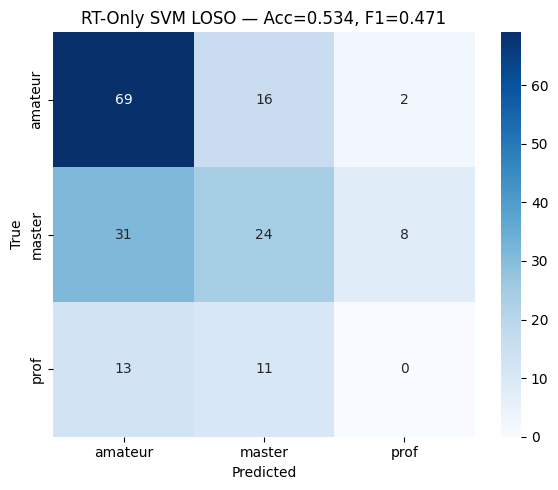

In [26]:
# ── Confusion Matrix ──

cm = confusion_matrix(all_true, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'RT-Only SVM LOSO — Acc={mean_acc:.3f}, F1={mean_f1:.3f}')
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\game_RT_time\svm_rt_only_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()

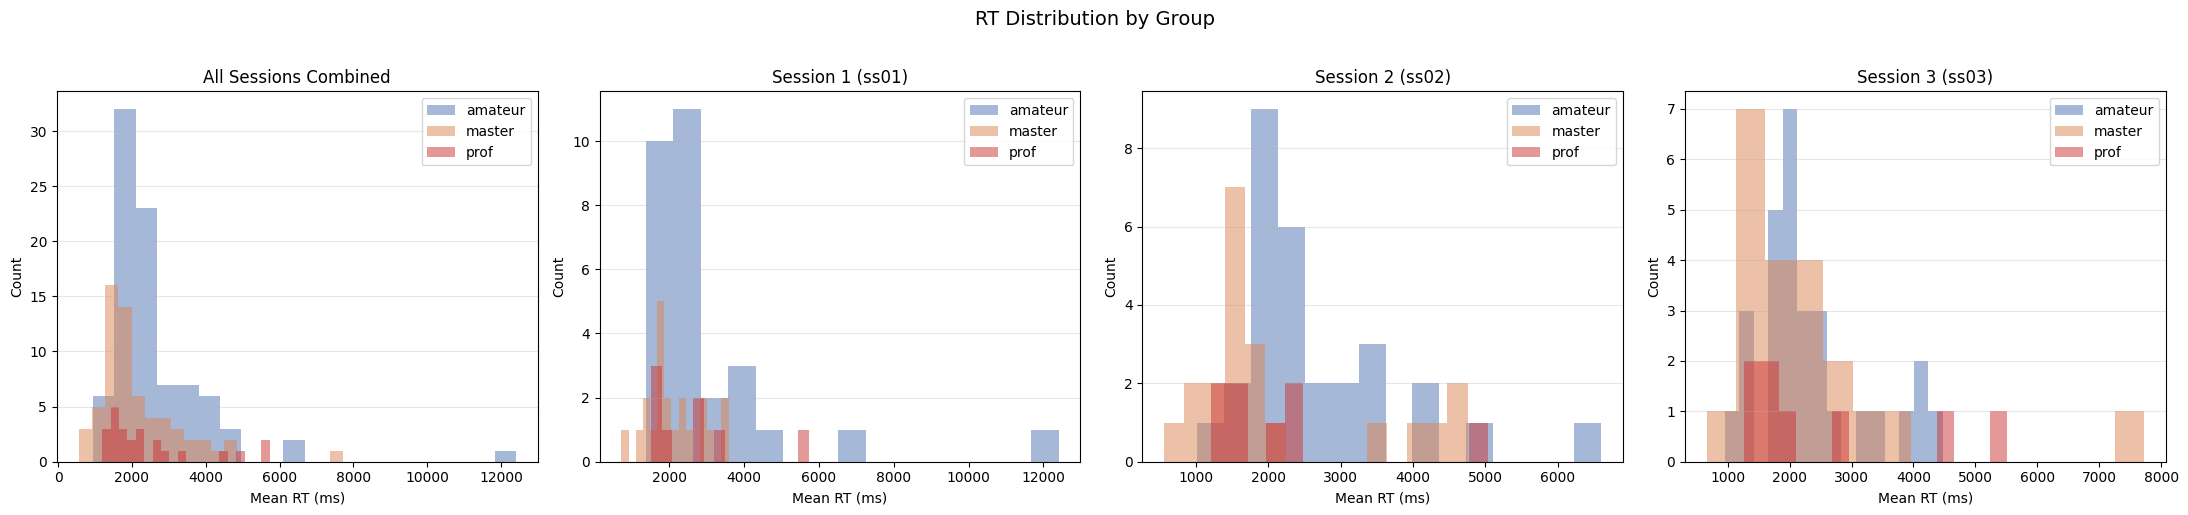


各組各 Session RT 統計 (ms):
Group      Session      Mean      Std   Median      Min      Max
------------------------------------------------------------
amateur    ss01       2976.9   2071.3   2263.4   1369.4  12404.5
amateur    ss02       2650.9   1141.2   2291.3   1010.2   6600.1
amateur    ss03       2365.7    881.0   2050.9    952.7   4476.4

master     ss01       2124.6    736.9   1879.3    723.9   3585.7
master     ss02       2132.7   1226.7   1583.6    559.6   4754.7
master     ss03       2232.9   1417.9   1719.8    666.3   7717.9

prof       ss01       2659.5   1318.0   2315.7   1524.9   5730.9
prof       ss02       2201.6   1140.3   1903.5   1200.9   5034.6
prof       ss03       2587.1   1446.2   1849.0   1262.3   5510.9



In [27]:
# ── 各組 RT 分布視覺化：總體 + 分 session ──

group_colors = {'amateur': '#4C72B0', 'master': '#DD8452', 'prof': '#CC3333'}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 左1: 總體
ax = axes[0]
for g in CLASS_NAMES:
    subset = rt_complete[rt_complete['Group'] == g]
    all_rt = subset[['ss01', 'ss02', 'ss03']].values.flatten()
    ax.hist(all_rt, bins=20, alpha=0.5, label=g, color=group_colors[g])
ax.set_xlabel('Mean RT (ms)')
ax.set_ylabel('Count')
ax.set_title('All Sessions Combined')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 右3: 分 session
for i, ss_col in enumerate(['ss01', 'ss02', 'ss03']):
    ax = axes[i + 1]
    for g in CLASS_NAMES:
        subset = rt_complete[rt_complete['Group'] == g]
        vals = subset[ss_col].values
        ax.hist(vals, bins=15, alpha=0.5, label=g, color=group_colors[g])
    ax.set_xlabel('Mean RT (ms)')
    ax.set_ylabel('Count')
    ax.set_title(f'Session {i+1} ({ss_col})')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('RT Distribution by Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\game_RT_time\rt_distribution_by_session.png',
            dpi=150, bbox_inches='tight')
plt.show()

# 各組各 session 統計
print('\n各組各 Session RT 統計 (ms):')
print(f'{"Group":<10s} {"Session":<8s} {"Mean":>8s} {"Std":>8s} {"Median":>8s} {"Min":>8s} {"Max":>8s}')
print('-' * 60)
for g in CLASS_NAMES:
    subset = rt_complete[rt_complete['Group'] == g]
    for ss_col in ['ss01', 'ss02', 'ss03']:
        vals = subset[ss_col].values
        print(f'{g:<10s} {ss_col:<8s} {np.mean(vals):8.1f} {np.std(vals):8.1f} '
              f'{np.median(vals):8.1f} {np.min(vals):8.1f} {np.max(vals):8.1f}')
    print()

In [28]:
# ── Per-subject accuracy 一覽 ──

print(f'{"Subject":<15s} {"Group":<10s} {"Acc":>6s} {"Pred":>20s}')
print('-' * 55)

for r in per_sub:
    sub = r['subject']
    true_g = CLASS_NAMES[r['true']]
    # 找這位 subject 的預測
    mask = sub_split == sub
    preds_sub = all_preds[mask]
    pred_str = ', '.join([CLASS_NAMES[int(p)] for p in preds_sub])
    print(f'{sub:<15s} {true_g:<10s} {r["acc"]:6.2f}  [{pred_str}]')

Subject         Group         Acc                 Pred
-------------------------------------------------------
sub-21          amateur      1.00  [amateur, amateur, amateur]
sub-22          amateur      1.00  [amateur, amateur, amateur]
sub-23          amateur      0.67  [amateur, master, amateur]
sub-24          amateur      0.00  [master, master, master]
sub-33          amateur      1.00  [amateur, amateur, amateur]
sub-38          amateur      0.33  [master, amateur, master]
sub-39          amateur      0.67  [amateur, master, amateur]
sub-40          amateur      1.00  [amateur, amateur, amateur]
sub-41          amateur      1.00  [amateur, amateur, amateur]
sub-42          amateur      0.67  [amateur, amateur, master]
sub-43          amateur      1.00  [amateur, amateur, amateur]
sub-44          amateur      0.33  [prof, prof, amateur]
sub-45          amateur      1.00  [amateur, amateur, amateur]
sub-46          amateur      1.00  [amateur, amateur, amateur]
sub-47          amate